In [ ]:
!pip install scikit-learn
!pip install torch

In [1]:
from sklearn.datasets import fetch_california_housing


dataset = fetch_california_housing(as_frame=True)

X = dataset.data

Y = dataset.target

print(X.head())
print(X.info())
print(X.describe())
print(Y.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    

In [2]:
import random
import numpy as np
import torch
def seed_everything(seed=42):

    random.seed(seed)


    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)

In [3]:

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import torch

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape, Y_train.shape)


batch_size = 128
X_train_tensor = torch.FloatTensor(np.array(X_train))
Y_train_tensor = torch.FloatTensor(np.array(Y_train))

X_test_tensor = torch.FloatTensor(np.array(X_test))
Y_test_tensor = torch.FloatTensor(np.array(Y_test))


train_data = TensorDataset(X_train_tensor, Y_train_tensor)
test_data = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last = True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True, drop_last = True)

X_batch, Y_batch = next(iter(train_loader))
X_batch.shape, Y_batch.shape


(16512, 8) (16512,)


(torch.Size([128, 8]), torch.Size([128]))

In [ ]:
from torch import nn
from torch.nn.functional import mse_loss

D_in, H, D_out = X_batch.shape[1], 64, 1

class MyModule(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(D_in, H),
        nn.ReLU(),
        nn.Linear(H,H),
        nn.ReLU(),
        nn.Linear(H, D_out)
    )

  def forward(self, X):
    return self.net(X)


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(torch.cuda.is_available())
model = MyModule()
model = model.to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)


True


epoch 1: loss: 24.31958878381786
epoch 2: loss: 0.9751439694266603
epoch 3: loss: 0.7596492473192955


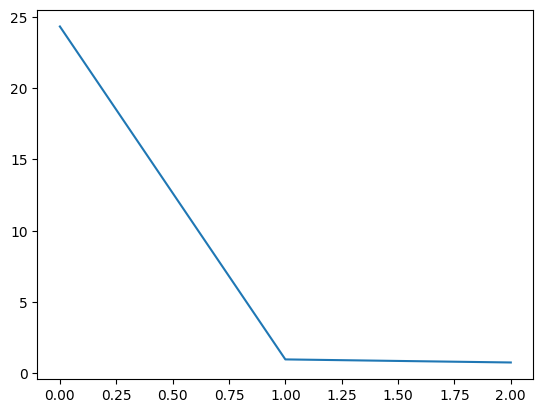

In [ ]:
import matplotlib.pyplot as plt
epochs = 3
history = []

for epoch in range(epochs):
  epoch_losses = []
  for x_batch, y_batch in train_data:

    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)


    y_pred = model(x_batch)

    loss = mse_loss(y_pred.view(-1), y_batch.view(-1))
    epoch_losses.append(loss.item())

    optim.zero_grad()

    loss.backward()

    optim.step()

  epoch_mean_loss = sum(epoch_losses) / len(epoch_losses)
  history.append(epoch_mean_loss)

  print(f"epoch {epoch+1}: loss: {history[-1]}")


plt.plot(history)


In [ ]:

model.eval()

test_losses = []
all_preds = []
all_targets = []


with torch.no_grad():
    for x_batch, y_batch in test_data:
        x_batch = x_batch.to(device).float()
        y_batch = y_batch.to(device).float()


        y_pred = model(x_batch)

        loss = mse_loss(y_pred.view(-1), y_batch.view(-1))
        test_losses.append(loss.item())


        all_preds.extend(y_pred.view(-1).cpu().numpy())
        all_targets.extend(y_batch.view(-1).cpu().numpy())


mean_test_loss = sum(test_losses) / len(test_losses)
print(f"Среднеквадратичная ошибка (MSE) на тестовых данных: {mean_test_loss:.4f}")


Среднеквадратичная ошибка (MSE) на тестовых данных: 0.6379
